# ADF Quantile: detecting structural break of the market.
- 1. We have a series of price data
- 2. Then, we can change start date t0, which range is [1,t-tau], to get a set of ADF value
- 3. Finally, we can get the ADF quantile and quantile fluctuation
### High quantile detect the bull market. Low Quantile detect the bear market
### Quantile fluctuation can be a supplement to volatility and might provide some new insight.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [4]:
# Feature
def CalculateADF(data, start_idx:int, end_idx:int):
    result = adfuller(data.iloc[start_idx:end_idx]['Log_P'], regression='c')[0]
    return result

def ADFQuantile(data, quantile, quantile_range, end_idx:int, max_win:int, min_win:int):

    if end_idx - max_win < 0 or min_win > max_win:
        return 0,0
    
    # For t0 = end_time-max_window,...,end_time-min_window, calculate the ADF
    date_region = range(end_idx-max_win,end_idx-min_win+1)
    ADF_values = []
    for start_idx in date_region:
        ADF_values.append(CalculateADF(data,start_idx,end_idx))
        
    result = np.quantile(ADF_values, quantile)
    quantile_fluctuation = np.quantile(ADF_values, quantile+quantile_range) - np.quantile(ADF_values, quantile-quantile_range)
    return result, quantile_fluctuation

def ADFQuantileSeries(data, quantile, quantile_range, start_idx:int, end_idx:int, max_win:int, min_win:int): 

    results = []

    for current_idx in range(start_idx,end_idx+1):
        result, quantile_fluctuation = ADFQuantile(data, quantile, quantile_range, current_idx, max_win, min_win)
        results.append([data.iloc[current_idx]['Datetime'], result, quantile_fluctuation])
    
    results = pd.DataFrame(results, columns=['Datetime', 'ADF Quantile', 'Quantile Fluctuation'])
    return results

In [6]:
# Read data for tests
WFC = yf.download('WFC', interval='1m', period='5d')
WFC.reset_index(inplace=True)
WFC.columns = WFC.columns.droplevel(1)
WFC = WFC[['Datetime','Close']]
WFC['Log_P'] = WFC['Close'].apply(np.log)

[*********************100%***********************]  1 of 1 completed


# Hear's two example of the feature
## 1. Low quantile indicates burst or bear market
## 2. High quantile indicates bubble or bull market

In [8]:
# Two examples: burst and bubble
# low quantile: 10%; quantile fluctuation: 5%
burst = ADFQuantileSeries(WFC, 0.10,0.05, 0, 1929, 30, 10)
burst = burst.merge(WFC[['Datetime', 'Log_P']], on='Datetime', how='left')

Text(0.5, 1.0, 'Bear-QADF and Log Return Over Time')

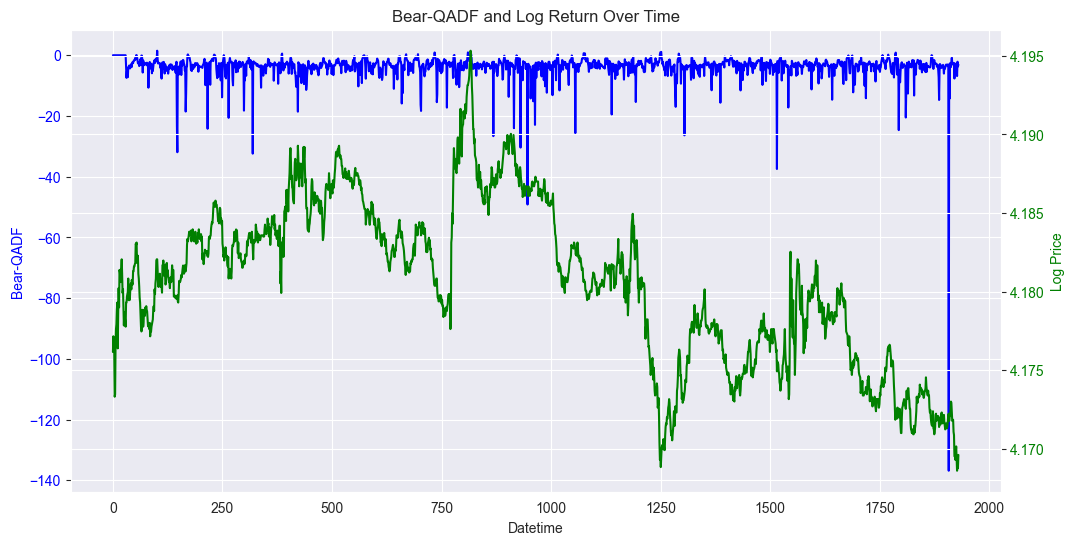

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Draw ADF Quantile
ax1.plot( burst['ADF Quantile'], color='b', label='Bear-QADF')
ax1.set_xlabel('Datetime')
ax1.set_ylabel('Bear-QADF', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Draw Log Return
ax2 = ax1.twinx()
ax2.plot(burst['Log_P'], color='g', label='Log Price')
ax2.set_ylabel('Log Price', color='g')
ax2.tick_params(axis='y', labelcolor='g')

plt.title("Bear-QADF and Log Return Over Time")

In [12]:
# High quantile: 90%; quantile fluctuation: 5%
bubble = ADFQuantileSeries(WFC, 0.90,0.05, 0, 1929, 30,10)
bubble = bubble.merge(WFC[['Datetime', 'Log_P']], on='Datetime', how='left')

Text(0.5, 1.0, 'Bull-QADF and Log Return Over Time')

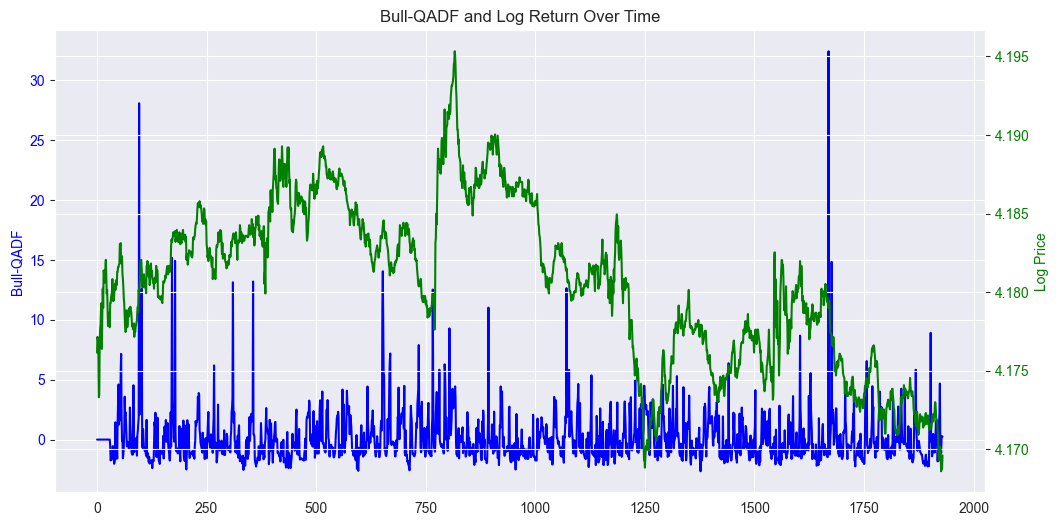

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Draw ADF Quantile
ax1.plot(bubble['ADF Quantile'], color='b', label='Bull-QADF')
ax1.set_ylabel('Bull-QADF', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Draw Log Return
ax2 = ax1.twinx()
ax2.plot(bubble['Log_P'], color='g', label='Log Price')
ax2.set_ylabel('Log Price', color='g')
ax2.tick_params(axis='y', labelcolor='g')
plt.title("Bull-QADF and Log Return Over Time")